# DCA Ingest - Datenanalyse
Dieses Notebook dient dem analysieren und exportieren von Daten des Digitalen Konstruktionsarchivs
Im ersten Schritt werden die Ergebnisse einer DROID-Analyse eingelesen.
Anschliessend können die Daten individuell analysiert werden.
Im letzten Schritt wird diese Analyse in RDF form festgehalten und zusammen mit den Metadaten des digitalen Materials exportiert.

## Imports und Setup

In [18]:
# =====================================================
# ENVIRONMENT SETUP & DEPENDENCIES
# =====================================================

from pathlib import Path
import pandas as pd
import csv
import json, subprocess, hashlib, sys, math, re, os, shutil
from datetime import datetime
from typing import Optional, Dict, List, Set, Union
import warnings
import logging
from urllib.parse import unquote

# RDF Core Libraries
from rdflib import Graph, Namespace, URIRef, BNode, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
from rdflib.plugins.serializers.turtle import TurtleSerializer

# Optional: Network analysis for provenance graphs
try:
    import networkx as nx
    NX_AVAILABLE = True
except ImportError:
    print("⚠️  NetworkX not available - provenance graphs disabled")
    NX_AVAILABLE = False

# Logging Setup für Pipeline-Tracking
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler(f'dca_pipeline_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
    ]
)
logger = logging.getLogger('DCA_Pipeline')

# Pipeline Status Tracking
pipeline_status = {
    'start_time': datetime.now(),
    'steps_completed': [],
    'steps_failed': [],
    'file_counts': {},
    'errors': []
}

def log_step(step_name: str, success: bool, details: str = ""):
    """Log pipeline step with status tracking"""
    timestamp = datetime.now().strftime('%H:%M:%S')
    if success:
        pipeline_status['steps_completed'].append(step_name)
        logger.info(f"✅ [{timestamp}] {step_name}: {details}")
    else:
        pipeline_status['steps_failed'].append(step_name)
        logger.error(f"❌ [{timestamp}] {step_name}: {details}")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("✅ All dependencies loaded successfully")
print(f"📅 DCA Integrated Pipeline started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"🔧 Python {sys.version_info.major}.{sys.version_info.minor}")
print(f"📚 RDFLib version: {getattr(Graph(), 'version', 'unknown')}")
print(f"📋 Log file: dca_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log")

log_step("Environment Setup", True, "All dependencies loaded")



✅ All dependencies loaded successfully
📅 DCA Integrated Pipeline started: 2026-03-25 12:17:35
🔧 Python 3.10
📚 RDFLib version: unknown
📋 Log file: dca_pipeline_20260325_121735.log
2026-03-25 12:17:35,600 - INFO - ✅ [12:17:35] Environment Setup: All dependencies loaded


## Konfiguration

Hier werden alle Pfade und Parameter definiert.

In [19]:
# Pfade
csv_path = "/Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/004_Work_DROIDresults.csv"

# Pfad zu src/ hinzufügen, um lokale Module zu importieren
src_path = "/Users/padrian/Documents/08_Tools/27_DCA_Ingest/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

output_dir = "/Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res"

print(f"Loading CSV file: {csv_path}")
print(f"src/ added to path: {src_path}")


Loading CSV file: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/004_Work_DROIDresults.csv
src/ added to path: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/src


## Analyse der DROID-Ergebnisse

Die folgenden Zellen führen verschiedene Analysen auf den DROID-Ergebnissen durch.

In [20]:
# ── DROID CSV laden ───────────────────────────────────────────────────────────
from dca_io import load_droid_csv_auto, analyze_droid_data

print(f"📂 Lade DROID CSV: {csv_path}")
droid_df = load_droid_csv_auto(csv_path)
analysis  = analyze_droid_data(droid_df)

print(f"📊 {len(droid_df):,} Einträge geladen")
print(f"🎯 Zieldateien (Bild/Adobe/CAD): {analysis.get('target_files', 0):,}")
if analysis.get('total_size_gb'):
    print(f"💾 Gesamtgröße: {analysis['total_size_gb']:.2f} GB")
if analysis.get('top_formats'):
    print("\n🏷️  Top-Formate:")
    for fmt, cnt in list(analysis['top_formats'].items())[:5]:
        print(f"   {fmt}: {cnt:,}")


📂 Lade DROID CSV: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/004_Work_DROIDresults.csv
⚠  22 Zeilen mit FORMAT_COUNT > 1 (zusätzliche Format-Felder verworfen, primärer Match behalten)
📊 216,283 Einträge geladen
🎯 Zieldateien (Bild/Adobe/CAD): 53,648
💾 Gesamtgröße: 1066.98 GB

🏷️  Top-Formate:
   Java Class File: 107,730
   : 45,561
   JPEG File Interchange Format: 26,629
   Portable Network Graphics: 19,771
   Binary File: 5,567


In [21]:
droid_df

,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION
0,1,NaN,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,004_Work,,Done,NaN,Folder,,2025-07-11T19:30:55,false,,NaN,,,,
1,2,1.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,Visualisations,,Done,NaN,Folder,,2021-06-26T20:33:02,false,,NaN,,,,
2,3,2.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,2022,,Done,NaN,Folder,,2022-02-14T13:31:07,false,,NaN,,,,
3,4,3.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,setction60.png,Signature,Done,2603443.0,File,png,2022-03-17T12:29:15,false,f99c92f378cb0d17b0cc28161a3375118ece1abbc3638c...,1.0,fmt/11,image/png,Portable Network Graphics,1.0
4,5,3.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,ScenesMulegns,,Done,NaN,Folder,,2022-06-14T00:10:09,false,,NaN,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216278,216279,216260.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,2023,,Done,NaN,Folder,,2023-02-12T04:55:08,false,,NaN,,,,
216279,216280,216279.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,230328_TowerDome.blend,Signature,Done,2442608.0,File,blend,2023-04-02T10:27:02,false,d1fc8e74a63a4f5ccbba2d0ed46c58a3635733dc4f392a...,1.0,fmt/903,,Blender 3D,64 bit
216280,216281,216279.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,TowerMembrane_15496_autosave.blend,Signature,Done,38799204.0,File,blend,2023-02-16T03:30:38,false,1e70f856b5fd21ef4da28888cee8ffd166f14ea3d33cb7...,1.0,fmt/903,,Blender 3D,64 bit
216281,216282,216279.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,TowerMembrane.blend,Signature,Done,38773808.0,File,blend,2023-02-12T04:54:33,false,32772580988cb2794140d14189cb291757602aa9c96916...,1.0,fmt/903,,Blender 3D,64 bit


In [22]:
# Alle Zeilen mit "Access denied" in STATUS, inkl. aller Spalten
df_access_denied = droid_df.loc[
    droid_df["STATUS"].astype(str).str.contains("Access denied", case=False, na=False),
    droid_df.columns
].copy()

print(f"Treffer: {len(df_access_denied):,}")
display(df_access_denied)

Treffer: 178


,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION
208492,208493,208374.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A2143.CR3,,Access denied,5.519522e+07,File,cr3,2022-07-12T16:25:40,false,,NaN,,,,
208496,208497,208374.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A2194.CR3,,Access denied,5.756578e+07,File,cr3,2022-07-12T16:57:36,false,,NaN,,,,
208497,208498,208374.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A2180.CR3,,Access denied,5.750588e+07,File,cr3,2022-07-12T16:45:12,false,,NaN,,,,
208499,208500,208374.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A2199.MP4,,Access denied,1.464796e+09,File,mp4,2022-07-12T17:04:00,false,,NaN,,,,
208501,208502,208374.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A2226.JPG,,Access denied,1.421246e+07,File,jpg,2022-07-12T17:27:48,false,,NaN,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214086,214087,214036.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A0580.CR3,,Access denied,1.183498e+08,File,cr3,2023-12-13T15:48:44,false,,NaN,,,,
214087,214088,214036.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A0557.CR3,,Access denied,1.095666e+08,File,cr3,2023-12-13T15:55:44,false,,NaN,,,,
214271,214272,214268.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,20231213_3.mp4,,Access denied,5.336486e+09,File,mp4,2024-05-26T21:09:27,false,,NaN,,,,
214274,214275,214268.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,20231213_1.mp4,,Access denied,4.750516e+09,File,mp4,2024-05-26T20:35:15,false,,NaN,,,,


In [23]:
# droid_df nach SIZE absteigend sortieren (NaN-Werte am Ende)
droid_df = droid_df.sort_values(by="SIZE", ascending=False, na_position="last")

# Kontrolle
droid_df.head(10)

,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION
213918,213919,213660.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1416.MP4,Signature,Done,1.742549e+10,File,mp4,2024-02-21T20:27:06,false,,1.0,fmt/199,"application/mp4, video/mp4",MPEG-4 Media File,
213927,213928,213660.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1412.MP4,Signature,Done,1.342779e+10,File,mp4,2024-02-21T20:30:57,false,,1.0,fmt/199,"application/mp4, video/mp4",MPEG-4 Media File,
214270,214271,214261.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A0577.MP4,Signature,Done,1.237418e+10,File,mp4,2023-12-13T15:54:28,false,,1.0,fmt/199,"application/mp4, video/mp4",MPEG-4 Media File,
213915,213916,213659.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,240221_TorAlvaStructuralTesting_Flat1.mp4,Signature,Done,9.255985e+09,File,mp4,2024-05-27T13:18:40,false,,1.0,fmt/199,"application/mp4, video/mp4",MPEG-4 Media File,
213919,213920,213659.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,240221_TorAlvaStructuralTesting_Flat2.mp4,,Done,9.183632e+09,File,mp4,2024-05-27T13:54:23,false,,0.0,,,,
113608,113609,113550.0,zip:file:///Users/padrian/Library/CloudStorage...,zip:/Users/padrian/Library/CloudStorage/Google...,test tower.obj,Signature,Done,7.341570e+09,File,obj,2021-03-24T11:18:38,false,8edacca2a16966a90ff30017a0cbaef81447844c435038...,1.0,fmt/1210,,Wavefront OBJ File,
210772,210773,210762.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,231028_ColumrHighreswithCol.blend,Signature,Done,7.304846e+09,File,blend,2023-10-29T15:18:23,false,a80103233b2a4daadcb1d4acfdf0b93081e22719bb567e...,1.0,fmt/903,,Blender 3D,64 bit
114333,114334,113711.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,231028_ColumrHighreswithCol.blend,Signature,Done,7.304846e+09,File,blend,2023-10-29T15:18:23,false,a80103233b2a4daadcb1d4acfdf0b93081e22719bb567e...,1.0,fmt/903,,Blender 3D,64 bit
213916,213917,213660.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A1413.MP4,Signature,Done,6.840633e+09,File,mp4,2024-02-21T20:28:24,false,,1.0,fmt/199,"application/mp4, video/mp4",MPEG-4 Media File,
215120,215121,214944.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,0J4A2129.MP4,Signature,Done,6.751766e+09,File,mp4,2024-03-14T00:12:12,false,88fc5ca2fb178acbcb9446fb4bbbf78b7493ff9f16fdcb...,1.0,fmt/199,"application/mp4, video/mp4",MPEG-4 Media File,


### Anzahl Dateien pro Format

Gefundene Formate: 89
FORMAT_NAME
Java Class File                                107730
JPEG File Interchange Format                    26629
Portable Network Graphics                       19771
Binary File                                      5567
Exchangeable Image File Format (Compressed)      3254
Canon Raw                                        2578
Windows Portable Executable                       972
Markdown                                          601
Graphics Interchange Format                       544
MPEG-4 Media File                                 516
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/format_counts.png


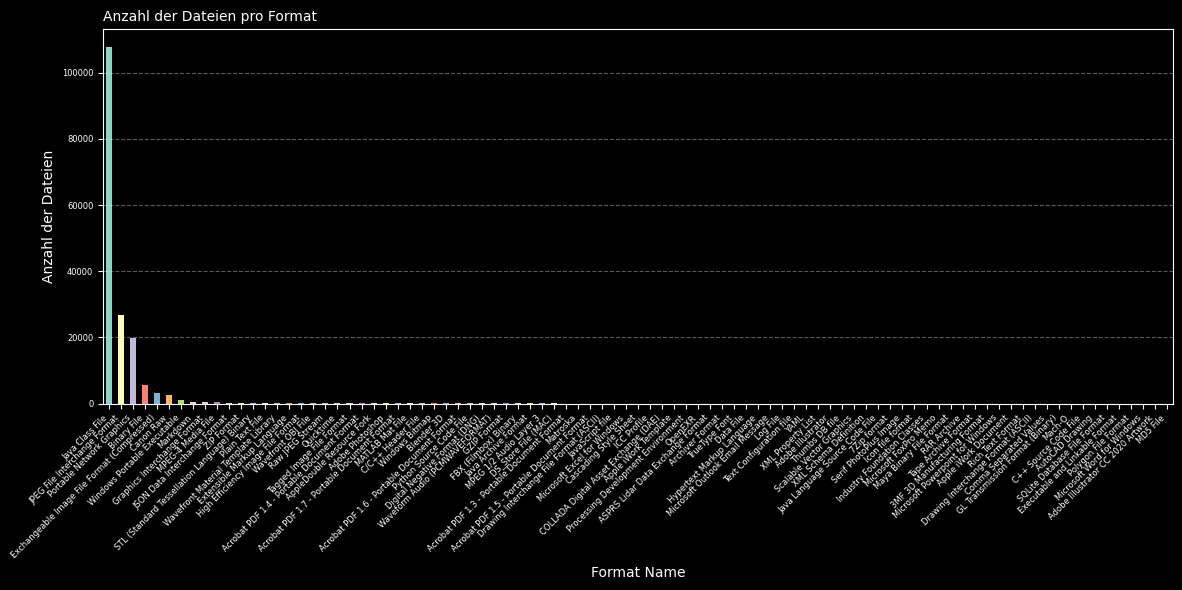

FORMAT_NAME
Java Class File                                107730
JPEG File Interchange Format                    26629
Portable Network Graphics                       19771
Binary File                                      5567
Exchangeable Image File Format (Compressed)      3254
                                                ...  
Executable and Linkable Format                      1
Polygon File Format                                 1
Microsoft Word for Windows                          1
Adobe Illustrator CC 2020 Artwork                   1
MD5 File                                            1
Name: count, Length: 89, dtype: int64

In [24]:
# Analyse: Anzahl der Dateien pro Format
from analyse_formats import analyse_formats_df

analyse_formats_df(droid_df, output_dir=output_dir, show_plot=True)


Kontext Java Class Files

In [25]:
# Kontext-Report für .class-Dateien auf Ebene der ZIP-Dateien
import re

df_class = droid_df[
    (droid_df["TYPE"].eq("File")) &
    (
        droid_df["EXT"].astype(str).str.lower().eq("class")
        | droid_df["FORMAT_NAME"].astype(str).str.contains("Java Class File", case=False, na=False)
    )
] .copy()

print(f"Gefundene .class-Dateien: {len(df_class):,}")

if df_class.empty:
    print("Keine .class-Dateien gefunden.")
else:
    def extract_zip_context(file_path: str) -> str:
        """Extrahiert den äußeren ZIP-Kontext aus einem DROID FILE_PATH.

        Beispiele:
        - zip:/.../viewer.zip!/inner/path -> /.../viewer.zip
        - zip:zip:/.../viewer.zip!/a.zip!/b.class -> /.../viewer.zip
        - ohne .zip im Pfad -> (kein ZIP-Kontext)
        """
        s = str(file_path)
        # Entferne wiederholte DROID-Prefixe wie zip:zip:
        while s.startswith("zip:"):
            s = s[4:]

        m = re.search(r"(.+?\.zip)!", s, flags=re.IGNORECASE)
        if m:
            return m.group(1)
        return "(kein ZIP-Kontext)"

    df_class["zip_kontext"] = df_class["FILE_PATH"].map(extract_zip_context)

    print("\nTop 20 ZIP-Dateien mit .class-Dateien:")
    print(df_class["zip_kontext"].value_counts().head(20).to_string())

    print("\nBeispiel-Dateien (erste 30):")
    print(
        df_class[["zip_kontext", "NAME", "FILE_PATH", "FORMAT_NAME", "LAST_MODIFIED", "SIZE", "STATUS"]]
        .sort_values(["zip_kontext", "NAME"])
        .head(5)
        .to_string(index=False)
    )

Gefundene .class-Dateien: 107,732

Top 20 ZIP-Dateien mit .class-Dateien:
zip_kontext
/Users/padrian/Library/CloudStorage/GoogleDrive-padrian@ethz.ch/Meine Ablage/004_Work/OBJ/2023/Ornaments cookbook 0222/ornament_viewer-winapp.zip    53865
(kein ZIP-Kontext)                                                                                                                                   53865
/Users/padrian/Library/CloudStorage/GoogleDrive-padrian@ethz.ch/Meine Ablage/004_Work/Unity/My project (5) 2.zip                                         2

Beispiel-Dateien (erste 30):
       zip_kontext                           NAME                                                                                                                                                                                                                                                         FILE_PATH     FORMAT_NAME       LAST_MODIFIED    SIZE STATUS
(kein ZIP-Kontext)                   AALOAD.class           

In [26]:
# Prüfung: Liegt dieselbe App gezippt und ungezippt vor?
import re

if "df_class" not in globals() or df_class.empty:
    print("df_class ist leer oder nicht vorhanden. Bitte zuerst die vorherige Zelle ausführen.")
else:
    # Schlüssel für Dateivergleich: NAME + SIZE (+ optional Hash-Spalte)
    key_cols = ["NAME", "SIZE"]
    hash_col = next((c for c in ["MD5_HASH", "HASH", "md5", "MD5"] if c in df_class.columns), None)
    if hash_col:
        key_cols.append(hash_col)

    work = df_class.copy()
    work["FILE_PATH"] = work["FILE_PATH"].astype(str)

    # ZIP-Datei (äußerster ZIP-Container) aus FILE_PATH extrahieren
    def extract_zip_file(path: str):
        s = path
        while s.startswith("zip:"):
            s = s[4:]
        m = re.search(r"(.+?\.zip)!", s, flags=re.IGNORECASE)
        return m.group(1) if m else None

    work["zip_file"] = work["FILE_PATH"].map(extract_zip_file)
    in_zip = work[work["zip_file"].notna()].copy()
    no_zip = work[work["zip_file"].isna()].copy()

    print(f".class in ZIP-Kontext: {len(in_zip):,}")
    print(f".class ohne ZIP-Kontext: {len(no_zip):,}")

    if in_zip.empty or no_zip.empty:
        print("Nicht genug Daten für den Vergleich (eine Seite ist leer).")
    else:
        keys_no_zip = set(map(tuple, no_zip[key_cols].fillna("").to_numpy()))

        rows = []
        for zip_file, group in in_zip.groupby("zip_file"):
            keys_zip = set(map(tuple, group[key_cols].fillna("").to_numpy()))
            overlap = len(keys_zip & keys_no_zip)
            total = len(keys_zip)
            ratio = (overlap / total * 100.0) if total else 0.0
            rows.append((zip_file, total, overlap, ratio))

        report = pd.DataFrame(rows, columns=["zip_file", "class_keys_zip", "matches_in_nozip", "match_percent"])
        report = report.sort_values(["matches_in_nozip", "match_percent"], ascending=False)

        print("\nZIP vs. Nicht-ZIP Überschneidung (Top 20):")
        print(report.head(20).to_string(index=False, formatters={"match_percent": lambda x: f"{x:6.2f}%"}))

        best = report.iloc[0]
        if best["matches_in_nozip"] > 0:
            print("\nWahrscheinlich liegt mindestens eine App gezippt und ungezippt vor.")
            print(f"Bester Treffer: {best['zip_file']}")
            print(f"Übereinstimmende .class-Keys: {int(best['matches_in_nozip']):,} von {int(best['class_keys_zip']):,} ({best['match_percent']:.2f}%)")

            # Konkrete ungezippten Pfade für den besten ZIP-Treffer anzeigen
            best_zip_file = best["zip_file"]
            best_zip_keys = set(
                map(
                    tuple,
                    in_zip.loc[in_zip["zip_file"] == best_zip_file, key_cols]
                    .fillna("")
                    .to_numpy(),
                )
            )

            no_zip_match = no_zip[
                no_zip[key_cols].fillna("").apply(tuple, axis=1).isin(best_zip_keys)
            ].copy()

            print("\nTop 20 ungezippten Pfade (matching):")
            print(no_zip_match["FILE_PATH"].value_counts().head(5).to_string())
        else:
            print("\nKeine Überschneidung gefunden: keine klare ZIP/No-ZIP-Doppelung nach den gewählten Schlüsseln.")

.class in ZIP-Kontext: 53,867
.class ohne ZIP-Kontext: 53,865

ZIP vs. Nicht-ZIP Überschneidung (Top 20):
                                                                                                                                         zip_file  class_keys_zip  matches_in_nozip match_percent
/Users/padrian/Library/CloudStorage/GoogleDrive-padrian@ethz.ch/Meine Ablage/004_Work/OBJ/2023/Ornaments cookbook 0222/ornament_viewer-winapp.zip           38153             38153       100.00%
                                 /Users/padrian/Library/CloudStorage/GoogleDrive-padrian@ethz.ch/Meine Ablage/004_Work/Unity/My project (5) 2.zip               2                 0         0.00%

Wahrscheinlich liegt mindestens eine App gezippt und ungezippt vor.
Bester Treffer: /Users/padrian/Library/CloudStorage/GoogleDrive-padrian@ethz.ch/Meine Ablage/004_Work/OBJ/2023/Ornaments cookbook 0222/ornament_viewer-winapp.zip
Übereinstimmende .class-Keys: 38,153 von 38,153 (100.00%)

Top 20 ungezippten Pfa

Einträge ohne .class-Dateien: 108,551 von 216,283
Gefundene Formate: 88
FORMAT_NAME
JPEG File Interchange Format                   26629
Portable Network Graphics                      19771
Binary File                                     5567
Exchangeable Image File Format (Compressed)     3254
Canon Raw                                       2578
Windows Portable Executable                      972
Markdown                                         601
Graphics Interchange Format                      544
MPEG-4 Media File                                516
JSON Data Interchange Format                     264
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/format_counts.png


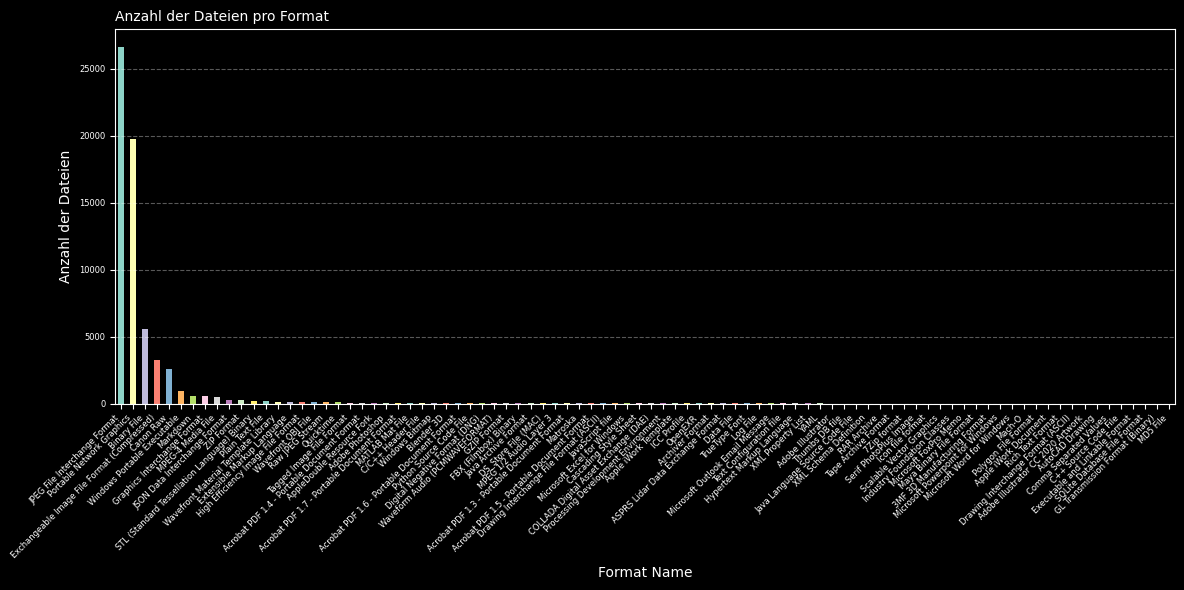

FORMAT_NAME
JPEG File Interchange Format                   26629
Portable Network Graphics                      19771
Binary File                                     5567
Exchangeable Image File Format (Compressed)     3254
Canon Raw                                       2578
                                               ...  
C++ Source Code File                               1
Executable and Linkable Format                     1
SQLite Database File Format                        1
GL Transmission Format (Binary)                    1
MD5 File                                           1
Name: count, Length: 88, dtype: int64

In [27]:
# Analyse: Anzahl der Dateien pro Format (ohne .class-Dateien)
from analyse_formats import analyse_formats_df

df_no_class = droid_df[~(
    droid_df["EXT"].astype(str).str.lower().eq("class")
    | droid_df["FORMAT_NAME"].astype(str).str.contains("Java Class File", case=False, na=False)
)].copy()

print(f"Einträge ohne .class-Dateien: {len(df_no_class):,} von {len(droid_df):,}")
analyse_formats_df(df_no_class, output_dir=output_dir, show_plot=True)

PRONOM Format Type hinzufügen

In [14]:
import requests
import xml.etree.ElementTree as ET

def fetch_pronom_format_type(puid):
    """
    Ruft PRONOM-XML für einen PUID ab und extrahiert den FormatType.
    """
    if pd.isna(puid) or puid == "":
        return None

    base_url = "https://www.nationalarchives.gov.uk/pronom/"
    url = f"{base_url}{puid}.xml"

    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code != 200:
            return None

        root = ET.fromstring(resp.content)
        ns = {"pr": "http://pronom.nationalarchives.gov.uk"}
        fmt_type = root.find(".//pr:FormatTypes", ns)

        return fmt_type.text.strip() if fmt_type is not None else None

    except Exception:
        return None


def map_pronom_format_types(droid_df):
    # 1) Alle einzigartigen PUIDs extrahieren
    unique_puids = droid_df["PUID"].dropna().unique()

    # 2) Dictionary zur Speicherung der FormatTypes erstellen
    puid_to_type = {}

    for puid in unique_puids:
        puid_to_type[puid] = fetch_pronom_format_type(puid)

    # 3) Neue Spalte in droid_df anlegen
    droid_df["PRONOM_FormatType"] = droid_df["PUID"].map(puid_to_type)

    return droid_df


# Beispielaufruf:
droid_df = map_pronom_format_types(droid_df)


Nach Format Typen gruppieren

Gefundene Formate: 20
PRONOM_FormatType
Image (Raster)         51141
Aggregate               5865
Text (Mark-up)           742
Audio, Video             430
Model                    369
Page Description         185
Video                     80
Text (Structured)         54
Text (Unstructured)       53
Audio                     39
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/format_counts.png


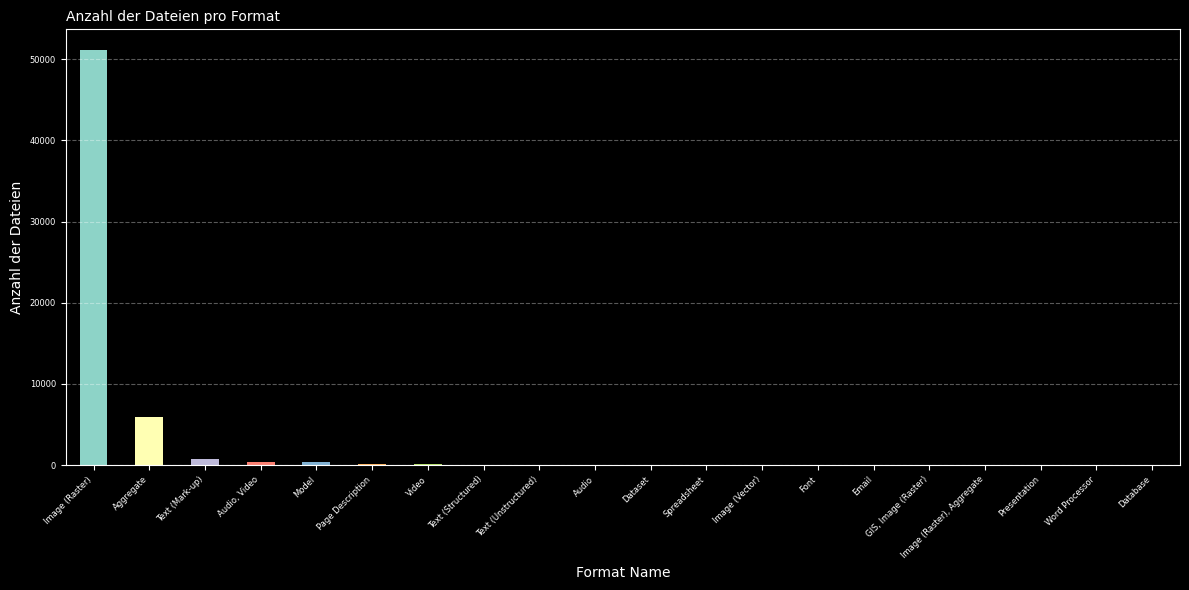

PRONOM_FormatType
Image (Raster)               51141
Aggregate                     5865
Text (Mark-up)                 742
Audio, Video                   430
Model                          369
Page Description               185
Video                           80
Text (Structured)               54
Text (Unstructured)             53
Audio                           39
Dataset                         19
Spreadsheet                     11
Image (Vector)                  10
Font                             8
Email                            7
GIS, Image (Raster)              4
Image (Raster), Aggregate        3
Presentation                     2
Word Processor                   1
Database                         1
Name: count, dtype: int64

In [31]:
from analyse_formats import analyse_formats_df

analyse_formats_df(
droid_df,
format_column="PRONOM_FormatType",
output_dir=output_dir,
show_plot=True,
top_n=20,
verbose=True
)

Aber: die grösste Gruppe (inkl. .class) hat keine Zuordnung zu einem Formattyp

In [27]:
sub = droid_df.copy()
sub["PRONOM_FormatType"] = sub["PRONOM_FormatType"].fillna("Unknown").astype(str).str.strip()
sub["FORMAT_NAME"] = sub["FORMAT_NAME"].fillna("Unknown").astype(str).str.strip()

by_type = sub["PRONOM_FormatType"].value_counts()

top_types = by_type.head(5).index
for t in top_types:
    print("\n=== ", t, " ===")
    print(
        sub.loc[sub["PRONOM_FormatType"] == t, "FORMAT_NAME"]
        .value_counts()
        .head(10)
        .to_string()
    )


===    ===
FORMAT_NAME
Java Class File                        107730
Windows Portable Executable               971
JSON Data Interchange Format              262
Plain Text File                           182
Wavefront Material Template Library       134
AppleDouble Resource Fork                  66
C/C++ Header File                          46
DS_Store File (MAC)                        16
JavaScript file                            12
Apple iWork Template                       10

===  Image (Raster)  ===
FORMAT_NAME
JPEG File Interchange Format                   26541
Portable Network Graphics                      19758
Exchangeable Image File Format (Compressed)     2275
Canon Raw                                       1658
Graphics Interchange Format                      544
Raw JPEG Stream                                   99
High Efficiency Image File Format                 75
Tagged Image File Format                          71
Adobe Photoshop                                   61
W

Anzahl im Formattyp Model

Einträge Formattyp Model: 369 von 213,722
Gefundene Formate: 9
FORMAT_NAME
STL (Standard Tessellation Language) Binary    210
Wavefront OBJ File                             100
Blender 3D                                      25
FBX (Filmbox) Binary                            18
COLLADA Digital Asset Exchange (DAE)            10
Maya Binary File Format                          2
3MF 3D Manufacturing Format                      2
Polygon File Format                              1
GL Transmission Format (Binary)                  1
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/format_counts.png


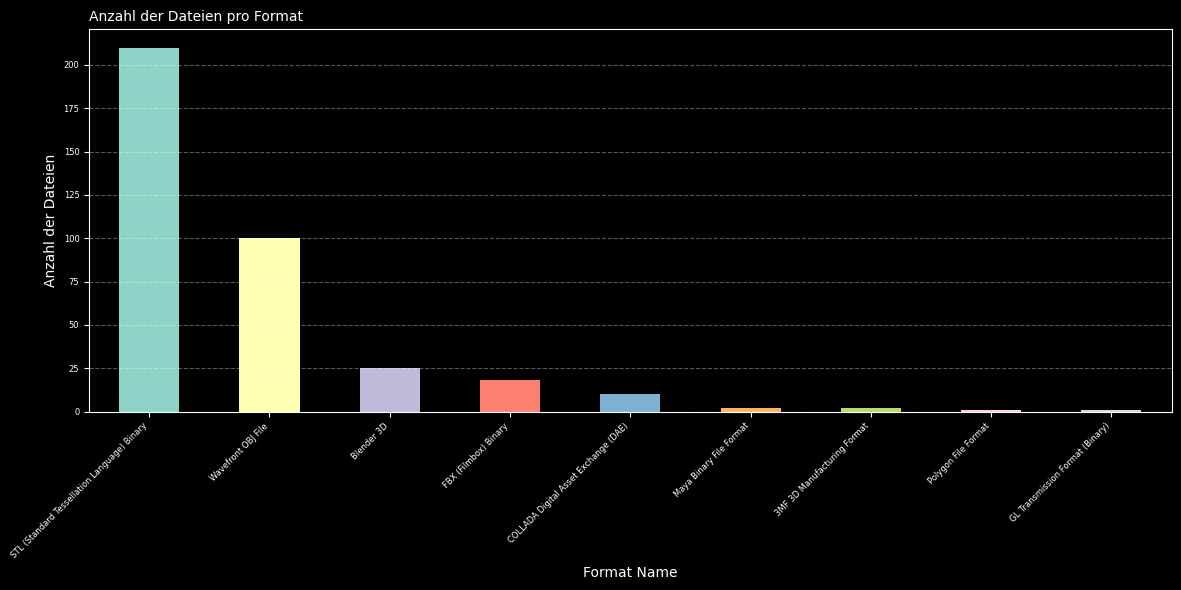

FORMAT_NAME
STL (Standard Tessellation Language) Binary    210
Wavefront OBJ File                             100
Blender 3D                                      25
FBX (Filmbox) Binary                            18
COLLADA Digital Asset Exchange (DAE)            10
Maya Binary File Format                          2
3MF 3D Manufacturing Format                      2
Polygon File Format                              1
GL Transmission Format (Binary)                  1
Name: count, dtype: int64

In [33]:
# Analyse: Anzahl der Dateien Formate mit Typ Model
from analyse_formats import analyse_formats_df
df_model = droid_df.copy()
df_model = df_model[(df_model["TYPE"] == "File") & (df_model["STATUS"] == "Done") & (df_model["PRONOM_FormatType"] == "Model") ].copy()

print(f"Einträge Formattyp Model: {len(df_model):,} von {len(droid_df):,}")
analyse_formats_df(df_model,format_column="FORMAT_NAME",output_dir=output_dir,show_plot=True,top_n=20,verbose=True)

3DM wurden nicht von Droid erkannt (erst seit Dezember 2025 in Pronom dokumentiert) und werden manuel zugeordnet.

Einträge Model (Basis): 369
Ergänzte 3dm-Einträge: 198
Einträge Model (kombiniert): 567 von 213,722
Gefundene Formate: 10
FORMAT_NAME
STL (Standard Tessellation Language) Binary    210
3DM                                            198
Wavefront OBJ File                             100
Blender 3D                                      25
FBX (Filmbox) Binary                            18
COLLADA Digital Asset Exchange (DAE)            10
3MF 3D Manufacturing Format                      2
Maya Binary File Format                          2
GL Transmission Format (Binary)                  1
Polygon File Format                              1
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/format_counts.png


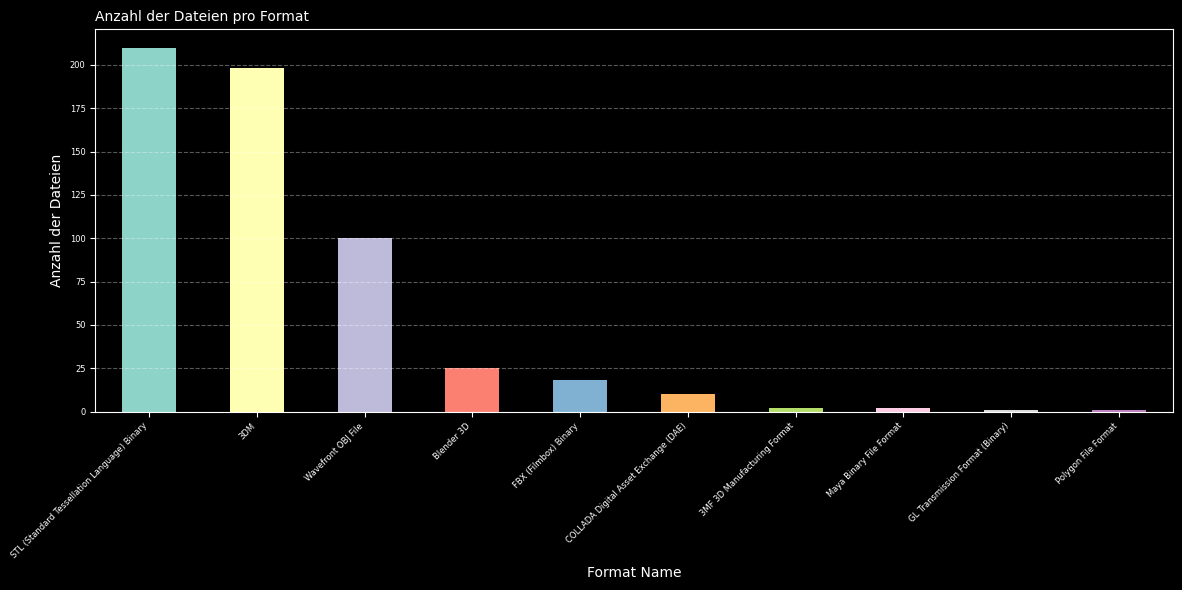


Alle Formate vom Typ Model (inkl. ergänztem 3dm):
FORMAT_NAME
STL (Standard Tessellation Language) Binary    210
3DM                                            198
Wavefront OBJ File                             100
Blender 3D                                      25
FBX (Filmbox) Binary                            18
COLLADA Digital Asset Exchange (DAE)            10
3MF 3D Manufacturing Format                      2
Maya Binary File Format                          2
GL Transmission Format (Binary)                  1
Polygon File Format                              1


In [15]:
# Wie Zelle 24, aber 3dm zusätzlich als Model ergänzen
from analyse_formats import analyse_formats_df

# 1) Basis wie in Zelle 24: nur PRONOM_FormatType == Model
df_model = droid_df.copy()
df_model = df_model[
    (df_model["TYPE"] == "File")
    & (df_model["STATUS"] == "Done")
    & (df_model["PRONOM_FormatType"] == "Model")
].copy()

# 2) Ergänzung: 3dm-Dateien auf Model setzen
df_model_3dm = droid_df.copy()
df_model_3dm = df_model_3dm[
    (df_model_3dm["TYPE"] == "File")
    & (df_model_3dm["STATUS"] == "Done")
    & (df_model_3dm["EXT"].astype(str).str.lower() == "3dm")
] .copy()

df_model_3dm["FORMAT_NAME"] = "3DM"
df_model_3dm["PRONOM_FormatType"] = "Model"

# 3) Zusammenführen und Duplikate entfernen
df_model_combined = pd.concat([df_model, df_model_3dm], ignore_index=True)
dedupe_cols = [c for c in ["ID", "FILE_PATH", "NAME", "SIZE"] if c in df_model_combined.columns]
if dedupe_cols:
    df_model_combined = df_model_combined.drop_duplicates(subset=dedupe_cols, keep="first")
else:
    df_model_combined = df_model_combined.drop_duplicates()

# 4) WICHTIG: Finale Filterung bleibt PRONOM_FormatType == Model
df_model_combined = df_model_combined[
    df_model_combined["PRONOM_FormatType"].astype(str).str.strip().eq("Model")
] .copy()

print(f"Einträge Model (Basis): {len(df_model):,}")
print(f"Ergänzte 3dm-Einträge: {len(df_model_3dm):,}")
print(f"Einträge Model (kombiniert): {len(df_model_combined):,} von {len(droid_df):,}")

all_model_counts = analyse_formats_df(
    df_model_combined,
    format_column="FORMAT_NAME",
    output_dir=output_dir,
    show_plot=True,
    top_n=None,
    verbose=True,
    )

print("\nAlle Formate vom Typ Model (inkl. ergänztem 3dm):")
print(all_model_counts.to_string())

Was ist mit IFC?

In [17]:
mask_ifc = droid_df["EXT"].astype(str).str.lower().eq("ifc")

print(f"Anzahl IFC-Dateien: {int(mask_ifc.sum()):,}")

if not mask_ifc.any():
    print("Keine Dateien mit EXT 'ifc' gefunden.")
else:
    display(droid_df.loc[mask_ifc])

Anzahl IFC-Dateien: 1


,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION,PRONOM_FormatType
114096,114097,114096.0,file:/Users/padrian/Library/CloudStorage/Googl...,/Users/padrian/Library/CloudStorage/GoogleDriv...,"Mulegns, Weisser Turm.ifc",Signature,Done,3694059.0,File,ifc,2023-11-01T14:18:37,false,dd97f64d4bbeb9e6801b115549cdf7a76197c6b2be6367...,1.0,fmt/699,,Industry Foundation Classes,2x3,Text (Structured)


In [8]:
# Analyse: Anzahl der Dateien Formate mit Typ Image (Raster)
from analyse_formats import analyse_formats_df
df_image = droid_df.copy()
df_image = df_image[(df_image["TYPE"] == "File") & (df_image["STATUS"] == "Done") & (df_image["PRONOM_FormatType"] == "Image (Raster)") ].copy()

print(f"Einträge Formattyp Image (Raster): {len(df_image):,} von {len(droid_df):,}")
analyse_formats_df(df_image,format_column="FORMAT_NAME",output_dir=output_dir,show_plot=True,top_n=20,verbose=True)

KeyError: 'PRONOM_FormatType'

### Häufigkeit Format X über Zeit

Gefilterte Zeilen für 'Java Class File' in Spalte 'FORMAT_NAME': 107730
Parsen abgeschlossen: 0 ungültige Datumswerte (von 107730)
_parsed_dt
2021-11-10         1
2022-09-09         1
2023-01-17    107728
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/FORMAT_NAME_Java Class File_counts.png


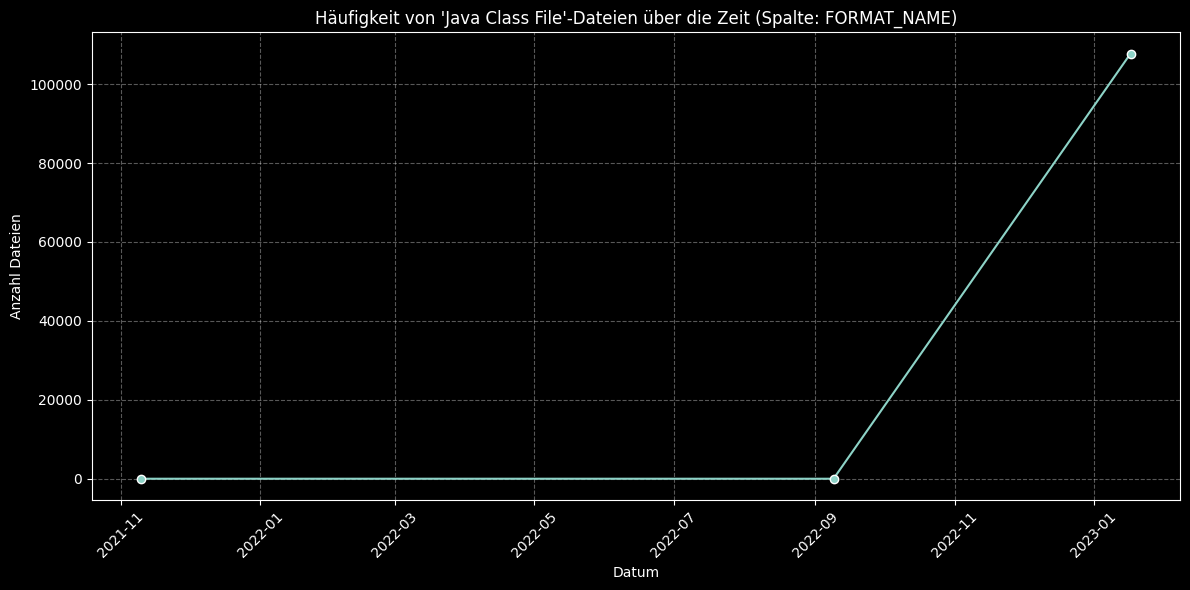

In [5]:
from analyse_format_over_creation_time import analyse_format_over_creation_time_df

most_common_format = droid_df["FORMAT_NAME"].dropna().astype(str).str.strip().value_counts().idxmax()
ts = analyse_format_over_creation_time_df(droid_df, most_common_format, date_column="LAST_MODIFIED", output_dir=output_dir, show_plot=True, verbose=True)


Gefilterte Zeilen für '3dm' in Spalte 'EXT': 198
Parsen abgeschlossen: 0 ungültige Datumswerte (von 198)
_parsed_dt
2020-04-21    1
2020-10-14    1
2020-12-16    2
2021-01-08    1
2021-02-03    1
2021-10-14    2
2021-12-04    1
2021-12-07    1
2021-12-14    2
2021-12-15    2
Name: count, dtype: int64
Plot gespeichert unter: /Users/padrian/Documents/08_Tools/27_DCA_Ingest/TorAlva_Metadata/004_Work_results/res/EXT_3dm_counts.png


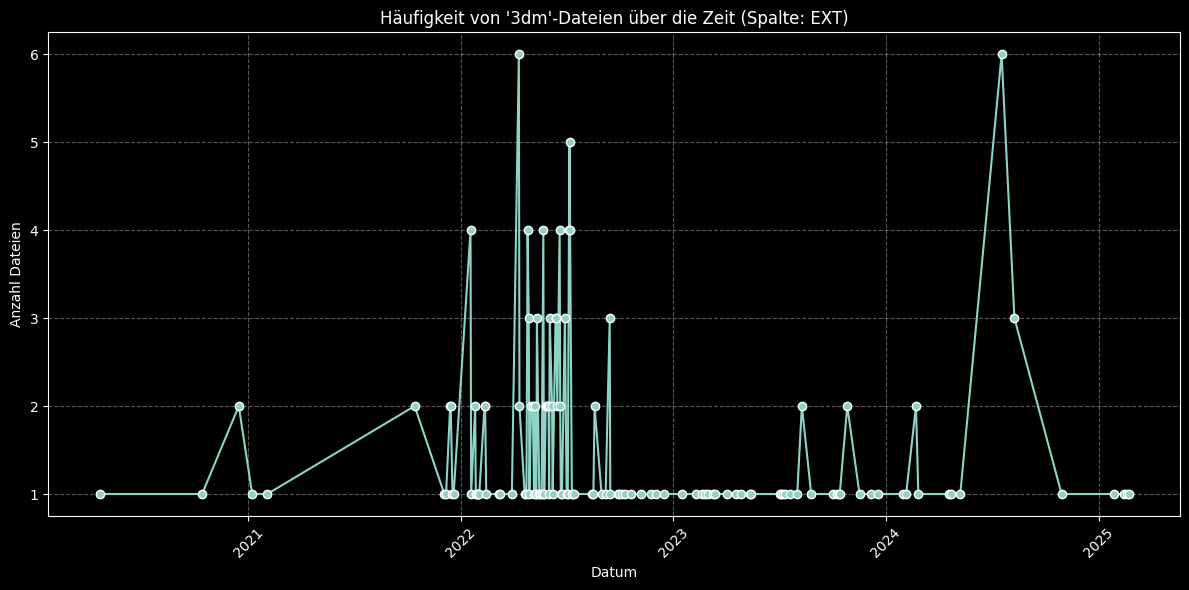

In [6]:
from analyse_format_over_creation_time import analyse_format_over_creation_time_df

format_name = "3dm"
ts = analyse_format_over_creation_time_df(droid_df, format_name, date_column="LAST_MODIFIED", output_dir=output_dir, show_plot=True, verbose=True)


In [7]:
print(droid_df[droid_df['EXT'].str.lower() == '3dm']['FORMAT_NAME'].value_counts())

FORMAT_NAME
                             194
MPEG 1/2 Audio Layer 3         3
AppleDouble Resource Fork      1
Name: count, dtype: int64


In [ ]:
# Jahresverteilung der 3dm-Dateien (Filter auf EXT — FORMAT_NAME enthält den vollen DROID-Namen)
df_3dm = droid_df.copy()
df_3dm['LAST_MODIFIED'] = pd.to_datetime(df_3dm['LAST_MODIFIED'], errors='coerce')
df_3dm = df_3dm[df_3dm['EXT'].str.lower() == '3dm']
print(f"Anzahl 3dm-Dateien: {len(df_3dm)}")
print(df_3dm['LAST_MODIFIED'].dt.year.value_counts().sort_index())


Anzahl 3DM-Zeilen: 0
count      0
mean     NaT
min      NaT
25%      NaT
50%      NaT
75%      NaT
max      NaT
Name: LAST_MODIFIED, dtype: object
Series([], Name: count, dtype: int64)


In [ ]:
# Identifizieren eines repräsentativen 3D Dokuments: Schritt 1 zeitliche Analyse

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

df = droid_df.copy()
df['LAST_MODIFIED'] = pd.to_datetime(df['LAST_MODIFIED'], errors='coerce')

def filter_3dm_files_by_dates(df, start_date, end_date):
    # DROID schreibt den vollen Namen in FORMAT_NAME (z.B. "Rhinoceros 3D Model").
    # Daher Filter auf EXT-Spalte (case-insensitive).
    start_date = pd.to_datetime(start_date)
    end_date   = pd.to_datetime(end_date)
    return df[
        (df['EXT'].str.lower() == '3dm') &
        (df['LAST_MODIFIED'].between(start_date, end_date))
    ]

result = filter_3dm_files_by_dates(df, '2021-01-01', '2023-12-31')
from IPython.display import display
display(result)


,ID,PARENT_ID,URI,FILE_PATH,NAME,METHOD,STATUS,SIZE,TYPE,EXT,LAST_MODIFIED,EXTENSION_MISMATCH,HASH,FORMAT_COUNT,PUID,MIME_TYPE,FORMAT_NAME,FORMAT_VERSION,ext_lower


In [ ]:
# Identifizieren eines repräsentativen 3D Dokuments: Schritt 2 kommentieren

# Kommentarspalte hinzufügen (einmalig, falls nicht vorhanden)
if 'comment' not in droid_df.columns:
    droid_df['comment'] = ''

# Kommentar in Zeile X hinzufügen
droid_df.loc[838, 'comment'] = 'Potentialy final 3D representation in Rhino'

# CSV überschreiben
droid_df.to_csv(csv_path, index=False)
print(f"Gespeichert: {csv_path}")


### Monatliche Dateihäufigkeit

Waffle-Chart für Zeitraum: 2011-2012
Plot gespeichert unter: /home/renku/work/dcaonnextcloud-500gb/dca-metadataraw/Keller/07_Plaene_Visualisierungen_results/res/waffle_files_per_month_2011_2012.png


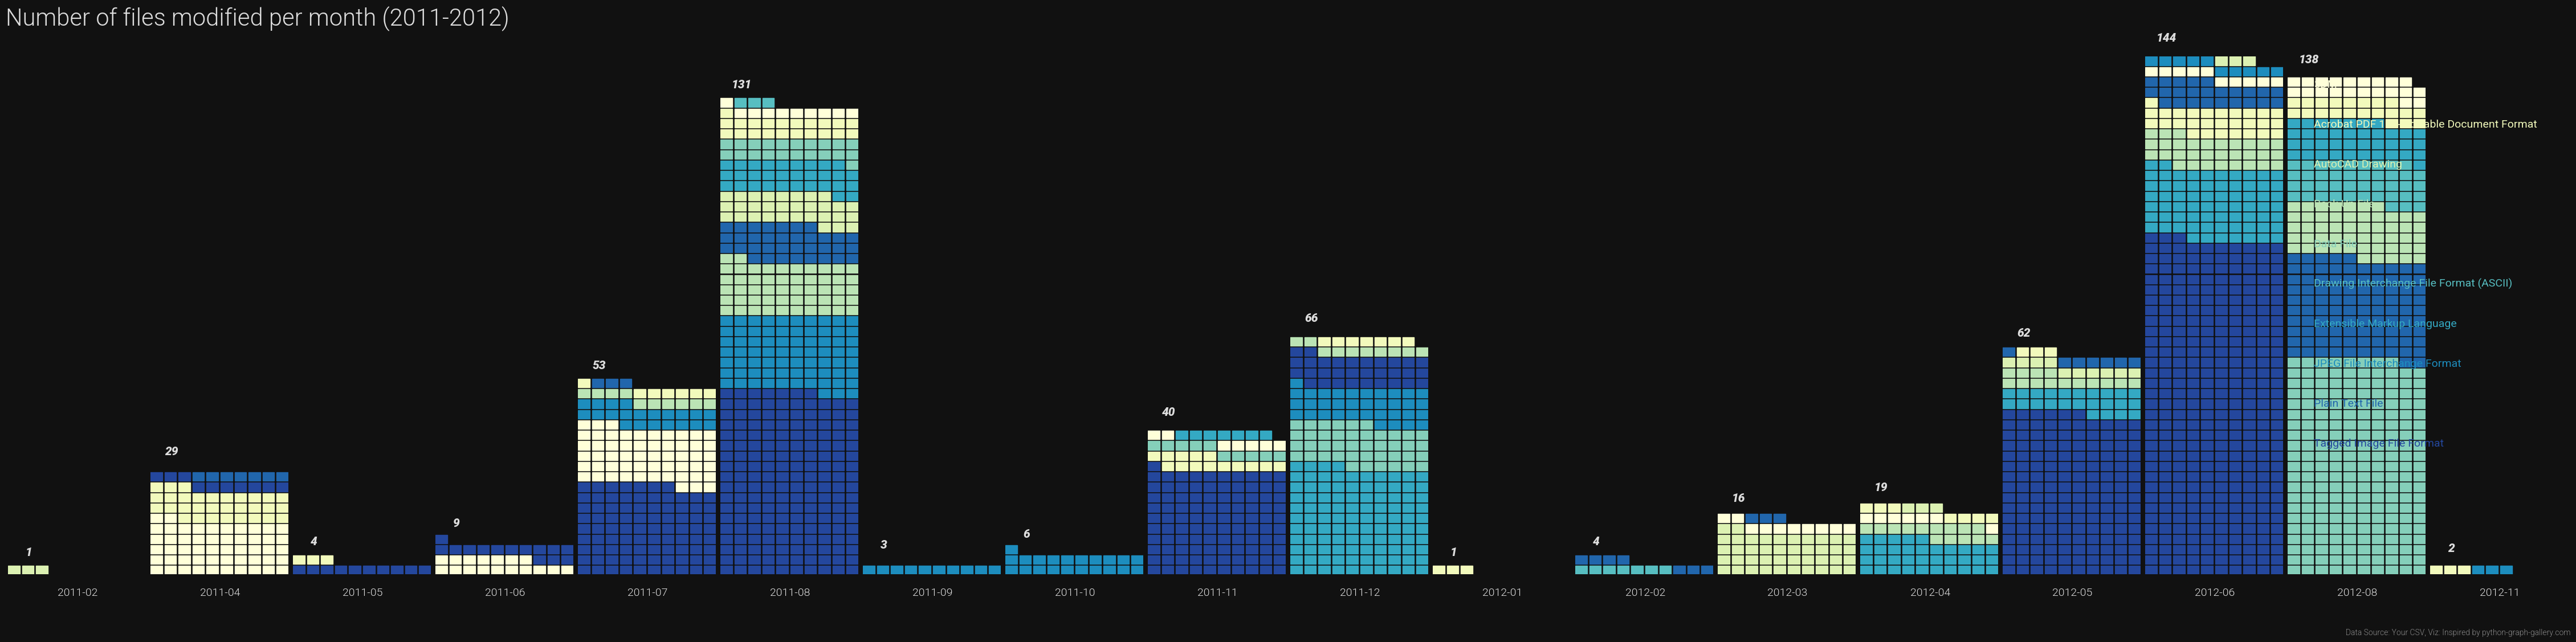

In [ ]:
# Analyse: Waffle-Chart für monatliche Dateihäufigkeit (verwende creation_iso)
from generate_waffle import generate_waffle_chart

df_waffle = droid_df.copy()
df_waffle["creation_iso"] = pd.to_datetime(df_waffle["creation_iso"], errors="coerce")
df_waffle = df_waffle.dropna(subset=["creation_iso"])

if len(df_waffle) > 0:
    start_year = 2011
    end_year = 2012
    print(f"Waffle-Chart für Zeitraum: {start_year}-{end_year}")
    generate_waffle_chart(df=df_waffle, output_dir=output_dir, start_year=start_year, end_year=end_year, top_n=10, show_plot=False, date_col="creation_iso")
else:
    print("Keine gültigen Datumsangaben in den Daten gefunden.")


### Finale Produktionsdaten

Gefilterte Zeilen für 'dat' in Spalte 'EXT': 93
Parsen abgeschlossen: 0 ungültige Datumswerte (von 93)
_parsed_dt
2010-10-18    12
2011-08-15     3
2011-08-17     3
2011-11-01     3
2011-12-13    12
2012-08-21    12
2012-08-28    48
Name: count, dtype: int64
Plot gespeichert unter: plots/EXT_dat_counts.png


/home/renku/work/27_DCA_Ingest/src/analyse_format_over_creation_time.py:43: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(s, errors='coerce', infer_datetime_format=True, utc=True)


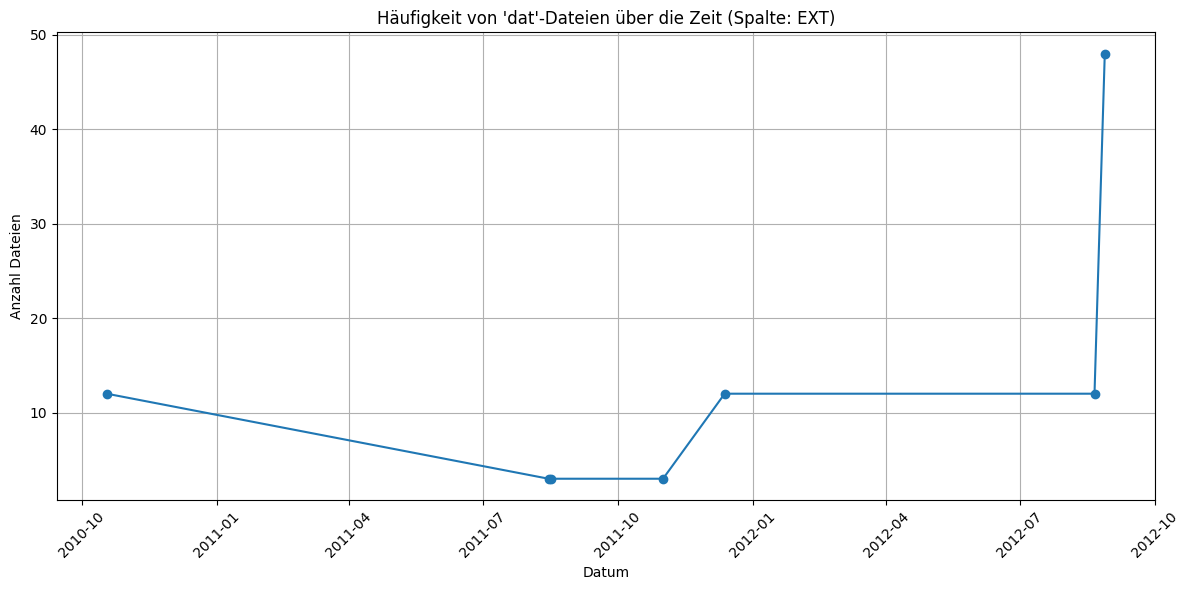

In [ ]:
# Nach dat-Dateien suchen (Steuerung KUKA Roboter) — src wird von DROID nicht als Format erkannt
from analyse_format_over_creation_time import analyse_format_over_creation_time_df

format_name = "dat"
ts = analyse_format_over_creation_time_df(droid_df, format_name, date_column="creation_iso", output_dir=output_dir, show_plot=True, verbose=True)


In [13]:
# Muss noch von LAST_MODIFIED auf creation_iso angepasst werden
# # Analyse: Heatmap der häufigsten Formate nach Monat
# try:
#     from analyse_format_heatmap import generate_format_heatmap
    
#     # Ermittle den Zeitraum aus den Daten
#     if os.path.exists(CSV_PATH):
#         df = pd.read_csv(CSV_PATH)
#         df["LAST_MODIFIED"] = pd.to_datetime(df["LAST_MODIFIED"], errors="coerce")
#         df_clean = df.dropna(subset=["LAST_MODIFIED"])
        
#         if len(df_clean) > 0:
#             start_year = df_clean["LAST_MODIFIED"].dt.year.min()
#             end_year = df_clean["LAST_MODIFIED"].dt.year.max()
#             print(f"Heatmap für Zeitraum: {start_year}-{end_year}")
#             generate_format_heatmap(CSV_PATH, OUTPUT_DIR, start_year, end_year, top_n=10, show_plot=False)
#         else:
#             print("Keine gültigen Datumsangaben in den Daten gefunden.")
#     else:
#         print(f"CSV-Datei nicht gefunden: {CSV_PATH}")
# except ImportError as e:
#     print(f"Hinweis: Modul nicht gefunden ({e}). Überspringe Heatmap.")
#     print("Installieren Sie seaborn falls benötigt: pip install seaborn")
# except Exception as e:
#     print(f"Fehler bei generate_format_heatmap: {e}")